# 🤖 NewsBot Intelligence System
## ITAI 2373 - Mid-Term Group Project Template

**Team Members:** Osemudia Ogedengbe
**Date:**  04/04/2026
**GitHub Repository:** [Add your repo URL here]

---

## 🎯 Project Overview

Welcome to your NewsBot Intelligence System! This notebook will guide you through building a comprehensive NLP system that:

- 📰 **Processes** news articles with advanced text cleaning
- 🏷️ **Classifies** articles into categories (Politics, Sports, Technology, Business, Entertainment, Health)
- 🔍 **Extracts** named entities (people, organizations, locations, dates, money)
- 😊 **Analyzes** sentiment and emotional tone
- 📊 **Generates** insights for business intelligence

### 📚 Module Integration Checklist
- [ ] **Module 1:** NLP applications and real-world context
- [ ] **Module 2:** Text preprocessing pipeline
- [ ] **Module 3:** TF-IDF feature extraction
- [ ] **Module 4:** POS tagging analysis
- [ ] **Module 5:** Syntax parsing and semantic analysis
- [ ] **Module 6:** Sentiment and emotion analysis
- [ ] **Module 7:** Text classification system
- [ ] **Module 8:** Named Entity Recognition

---

In [9]:
# Step 1: Install Kaggle API
!pip install kaggle

# Step 2: Upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Step 3: Set up API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API setup complete!")

# Download News Category Dataset
!kaggle datasets download -d rmisra/news-category-dataset

# Unzip the files
!unzip news-category-dataset.zip

# Load and sample the dataset (it's large!)
import pandas as pd
import json

# Load the JSON file
with open('News_Category_Dataset_v3.json', 'r') as f:
    data = [json.loads(line) for line in f]

# Convert to DataFrame
df = pd.DataFrame(data)

# Sample to manageable size for Colab
df_sample = df.sample(n=700, random_state=42)

print(f"Original dataset shape: {df.shape}")
print(f"Sampled dataset shape: {df_sample.shape}")
print(f"Categories: {df_sample['category'].unique()}")

Please upload your kaggle.json file:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API setup complete!
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
news-category-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  news-category-dataset.zip
replace News_Category_Dataset_v3.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
Original dataset shape: (209527, 6)
Sampled dataset shape: (700, 6)
Categories: ['IMPACT' 'BUSINESS' 'POLITICS' 'GREEN' 'SCIENCE' 'PARENTING' 'WELLNESS'
 'STYLE & BEAUTY' 'QUEER VOICES' 'EDUCATION' 'BLACK VOICES' 'TRAVEL'
 'DIVORCE' 'HEALTHY LIVING' 'TASTE' 'THE WORLDPOST' 'COMEDY' 'WORLDPOST'
 'ENTERTAINMENT' 'STYLE' 'FOOD & DRINK' 'HOME & LIVING' 'GOOD NEWS'
 'MEDIA' 'SPORTS' 'CRIME' 'MONEY' 'WORLD NEWS' 'COLLEGE' 'RELIGION'
 'WOMEN' 'PARENTS' 'ARTS' 'ARTS & CULTURE' 'ENVIRONMENT

In [10]:
# Data preparation template
import pandas as pd
import numpy as np

# 1. Examine your dataset
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

# 2. Identify text and category columns
# Adjust these column names based on your dataset
text_column = 'headline'  # or 'description', 'content', 'headline', etc.
category_column = 'category'  # or 'label', 'class', etc.

# 3. Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# 4. Remove rows with missing text or categories
df_clean = df.dropna(subset=[text_column, category_column])

# 5. Check category distribution
print(f"\nCategory distribution:")
print(df_clean[category_column].value_counts())

# 6. Sample if dataset is too large (keep under 2000 for Colab)
if len(df_clean) > 700:
    df_final = df_clean.sample(n=700, random_state=42)
    print(f"\nSampled dataset to {len(df_final)} rows")
else:
    df_final = df_clean

# 7. Rename columns for consistency
df_final = df_final.rename(columns={
    text_column: 'content',
    category_column: 'category'
})

# 8. Save prepared dataset
df_final.to_csv('newsbot_dataset.csv', index=False)
print("\n✅ Dataset prepared and saved as 'newsbot_dataset.csv'")

Dataset Info:
Shape: (209527, 6)
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

First few rows:
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict.

In [11]:
# Download NLTK data
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')

print("✅ All packages installed successfully!")

# Import all necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

✅ All packages installed successfully!


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


## 🧹 Text Preprocessing Pipeline

### 🎯 Module 2: Advanced Text Preprocessing

Now we'll implement a comprehensive text preprocessing pipeline that cleans and normalizes our news articles. This is crucial for all downstream NLP tasks.

**Key Preprocessing Steps:**
1. **Text Cleaning:** Remove HTML, URLs, special characters
2. **Tokenization:** Split text into individual words
3. **Normalization:** Convert to lowercase, handle contractions
4. **Stop Word Removal:** Remove common words that don't carry meaning
5. **Lemmatization:** Reduce words to their base form

**💡 Think About:** Why is preprocessing so important? What happens if we skip these steps?

In [12]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Comprehensive text cleaning function

    💡 TIP: This function should handle:
    - HTML tags and entities
    - URLs and email addresses
    - Special characters and numbers
    - Extra whitespace
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # 🚀 YOUR CODE HERE: Implement text cleaning
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Complete preprocessing pipeline

    💡 TIP: This function should:
    - Clean the text
    - Tokenize into words
    - Remove stop words (optional)
    - Lemmatize words (optional)
    - Return processed text
    """
    # Clean text
    text = clean_text(text)

    if not text:
        return ""

    # 🚀 YOUR CODE HERE: Implement tokenization and preprocessing
    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words if requested
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize if requested
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Filter out very short words
    tokens = [token for token in tokens if len(token) > 2]

    return ' '.join(tokens)

# Test the preprocessing function
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews"
print("Original text:")
print(sample_text)
print("\nCleaned text:")
print(clean_text(sample_text))
print("\nFully preprocessed text:")
print(preprocess_text(sample_text))

Original text:
Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews

Cleaned text:
apple inc announced record quarterly earnings today visit for more info technews

Fully preprocessed text:
apple inc announced record quarterly earnings today visit info technews


In [13]:
# Apply preprocessing to the dataset
print("🧹 Preprocessing all articles...")

# Create new columns for processed text on the sampled DataFrame
df_sample['link_clean'] = df_sample['link'].apply(clean_text)
df_sample['headline_clean'] = df_sample['headline'].apply(clean_text)
df_sample['category_processed'] = df_sample['category'].apply(preprocess_text)
df_sample['short_description_processed'] = df_sample['short_description'].apply(preprocess_text)
df_sample['authors_clean'] = df_sample['authors'].apply(clean_text)
df_sample['date_clean'] = df_sample['date'].apply(clean_text)

# Combine title and content for full article analysis on the sampled DataFrame
df_sample['full_text'] = df_sample['headline'] + ' ' + df_sample['short_description']
df_sample['full_text_processed'] = df_sample['full_text'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# Show before and after examples
print("\n📝 BEFORE AND AFTER EXAMPLES")
print("=" * 60)
for i in range(min(3, len(df_sample))):
    print(f"\nExample {i+1}:")
    print(f"Original: {df_sample.iloc[i]['full_text'][:100]}...")
    print(f"Processed: {df_sample.iloc[i]['full_text_processed'][:100]}...")

# 💡 STUDENT TASK: Analyze the preprocessing results
# - Calculate average text length before and after
# - Count unique words before and after
# - Identify the most common words after preprocessing

🧹 Preprocessing all articles...
✅ Preprocessing complete!

📝 BEFORE AND AFTER EXAMPLES

Example 1:
Original: What If We Were All Family Generation Changers? What if, in doing so, we won't just create new oppor...
Processed: family generation changer wont create new opportunity well also uncover way create new opportunity f...

Example 2:
Original: Firestorm At AOL Over Employee Benefit Cuts It should have been a glorious week for AOL chief execut...
Processed: firestorm aol employee benefit cut glorious week aol chief executive tim armstrong company quarterly...

Example 3:
Original: Dakota Access Protesters Arrested As Deadline Passes To Depart Camp A few protesters who refused to ...
Processed: dakota access protester arrested deadline pass depart camp protester refused leave remained site thu...


## 📊 Feature Extraction and Statistical Analysis

### 🎯 Module 3: TF-IDF Analysis

Now we'll extract numerical features from our text using TF-IDF (Term Frequency-Inverse Document Frequency). This technique helps us identify the most important words in each document and across the entire corpus.

**TF-IDF Key Concepts:**
- **Term Frequency (TF):** How often a word appears in a document
- **Inverse Document Frequency (IDF):** How rare a word is across all documents
- **TF-IDF Score:** TF × IDF - balances frequency with uniqueness

**💡 Business Value:** TF-IDF helps us identify the most distinctive and important terms for each news category.

In [14]:
# Create TF-IDF vectorizer
# 💡 TIP: Experiment with different parameters:
# - max_features: limit vocabulary size
# - ngram_range: include phrases (1,1) for words, (1,2) for words+bigrams
# - min_df: ignore terms that appear in less than min_df documents
# - max_df: ignore terms that appear in more than max_df fraction of documents

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary for computational efficiency
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.8  # Ignore terms that appear in more than 80% of documents
)

# Fit and transform the processed text
print("🔢 Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['full_text_processed'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix created!")
print(f"📊 Shape: {tfidf_matrix.shape}")
print(f"📝 Vocabulary size: {len(feature_names)}")
print(f"🔢 Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.4f}%")

# Convert to DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['category'] = df_sample['category'].values

print("\n🔍 Sample TF-IDF features:")
print(tfidf_df.iloc[:3, :10])  # Show first 3 rows and 10 features

🔢 Creating TF-IDF features...
✅ TF-IDF matrix created!
📊 Shape: (700, 1980)
📝 Vocabulary size: 1980
🔢 Sparsity: 99.4040%

🔍 Sample TF-IDF features:
   ability  able  absolutely  abuse    access  accomplish  according  account  \
0      0.0   0.0         0.0    0.0  0.000000         0.0        0.0      0.0   
1      0.0   0.0         0.0    0.0  0.000000         0.0        0.0      0.0   
2      0.0   0.0         0.0    0.0  0.265626         0.0        0.0      0.0   

   accused  achieve  
0      0.0      0.0  
1      0.0      0.0  
2      0.0      0.0  


In [15]:
# Analyze most important terms per category
def get_top_tfidf_terms(category, n_terms=10):
    """
    Get top TF-IDF terms for a specific category

    💡 TIP: This function should:
    - Filter data for the specific category
    - Calculate mean TF-IDF scores for each term
    - Return top N terms with highest scores
    """
    # 🚀 YOUR CODE HERE: Implement category-specific TF-IDF analysis
    category_data = tfidf_df[tfidf_df['category'] == category]

    # Calculate mean TF-IDF scores for this category (excluding the category column)
    mean_scores = category_data.drop('category', axis=1).mean().sort_values(ascending=False)

    return mean_scores.head(n_terms)

# Analyze top terms for each category
print("🏷️ TOP TF-IDF TERMS BY CATEGORY")
print("=" * 50)

categories = df['category'].unique()
category_terms = {}

for category in categories:
    top_terms = get_top_tfidf_terms(category, n_terms=10)
    category_terms[category] = top_terms

    print(f"\n📰 {category.upper()}:")
    for term, score in top_terms.items():
        print(f"  {term}: {score:.4f}")

# 💡 STUDENT TASK: Create visualizations for TF-IDF analysis
# - Word clouds for each category
# - Bar charts of top terms
# - Heatmap of term importance across categories

🏷️ TOP TF-IDF TERMS BY CATEGORY

📰 U.S. NEWS:
  war: 0.0934
  toddler: 0.0784
  fire: 0.0739
  reveal: 0.0582
  near: 0.0582
  final: 0.0556
  sentenced: 0.0552
  yearold woman: 0.0552
  said: 0.0539
  china: 0.0527

📰 COMEDY:
  trump: 0.0690
  stephen: 0.0444
  totally: 0.0429
  donald trump: 0.0408
  donald: 0.0408
  troll: 0.0403
  going: 0.0380
  funny: 0.0374
  late: 0.0371
  care: 0.0331

📰 PARENTING:
  child: 0.0761
  year: 0.0405
  little: 0.0363
  baby: 0.0349
  daughter: 0.0334
  day: 0.0334
  family: 0.0317
  mom: 0.0297
  get: 0.0291
  like: 0.0288

📰 WORLD NEWS:
  conflict: 0.0835
  university: 0.0830
  rule: 0.0788
  impact: 0.0741
  iran: 0.0740
  global: 0.0736
  official: 0.0673
  muslim: 0.0673
  china: 0.0643
  public: 0.0615

📰 CULTURE & ARTS:
  space: 0.2719
  something: 0.2554
  pop: 0.2137
  culture: 0.1996
  girl photo: 0.1423
  every woman: 0.1423
  artist: 0.1311
  air: 0.1270
  meet: 0.1207
  art: 0.1207

📰 TECH:
  apple: 0.1278
  iphone: 0.0980
  victim: 0.0

## 🏷️ Part-of-Speech Analysis

### 🎯 Module 4: Grammatical Pattern Analysis

Let's analyze the grammatical patterns in different news categories using Part-of-Speech (POS) tagging. This can reveal interesting differences in writing styles between categories.

**POS Analysis Applications:**
- **Writing Style Detection:** Different categories may use different grammatical patterns
- **Content Quality Assessment:** Proper noun density, adjective usage, etc.
- **Feature Engineering:** POS tags can be features for classification

**💡 Hypothesis:** Sports articles might have more action verbs, while business articles might have more numbers and proper nouns.

In [16]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

def analyze_pos_patterns(text):
    """
    Analyze POS patterns in text

    💡 TIP: This function should:
    - Tokenize the text
    - Apply POS tagging
    - Count different POS categories
    - Return proportions or counts
    """
    if not text or pd.isna(text):
        return {}

    # 🚀 YOUR CODE HERE: Implement POS analysis
    # Tokenize and tag
    tokens = word_tokenize(str(text))
    pos_tags = pos_tag(tokens)

    # Count POS categories
    pos_counts = Counter([tag for word, tag in pos_tags])
    total_words = len(pos_tags)

    if total_words == 0:
        return {}

    # Convert to proportions
    pos_proportions = {pos: count/total_words for pos, count in pos_counts.items()}

    return pos_proportions

# Apply POS analysis to all articles
print("🏷️ Analyzing POS patterns...")

# Analyze POS for each article
pos_results = []
for idx, row in df_sample.iterrows(): # Changed from df.iterrows() to df_sample.iterrows()
    pos_analysis = analyze_pos_patterns(row['full_text'])
    pos_analysis['category'] = row['category']
    pos_analysis['article_id'] = idx # Use the row index as article_id
    pos_results.append(pos_analysis)

# Convert to DataFrame
pos_df = pd.DataFrame(pos_results).fillna(0)

print(f"✅ POS analysis complete!")
print(f"📊 Found {len(pos_df.columns)-2} different POS tags")

# Show sample results
print("\n📝 Sample POS analysis:")
print(pos_df.head())

🏷️ Analyzing POS patterns...


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


✅ POS analysis complete!
📊 Found 43 different POS tags

📝 Sample POS analysis:
         WP        IN       PRP       VBP        DT       NNP         .  \
0  0.044444  0.111111  0.066667  0.022222  0.022222  0.066667  0.044444   
1  0.000000  0.066667  0.033333  0.000000  0.033333  0.333333  0.033333   
2  0.043478  0.086957  0.000000  0.000000  0.043478  0.434783  0.043478   
3  0.000000  0.083333  0.083333  0.000000  0.083333  0.333333  0.000000   
4  0.000000  0.078947  0.026316  0.026316  0.078947  0.157895  0.026316   

          ,       VBG        RB  ...  JJS   EX    $  NNPS  RBS  PDT   UH   FW  \
0  0.066667  0.022222  0.133333  ...  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
1  0.033333  0.000000  0.000000  ...  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
2  0.000000  0.000000  0.000000  ...  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
3  0.000000  0.000000  0.000000  ...  0.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
4  0.078947  0.000000  0.078947  ...  0.0  0.0  0.0   0.0  0.0  0

📊 POS PATTERNS BY CATEGORY

🎯 Key POS patterns by category:
                    NN     NNS     NNP    NNPS      VB     VBD     VBG  \
category                                                                 
ARTS            0.1208  0.0338  0.2938  0.0179  0.0215  0.0043  0.0000   
ARTS & CULTURE  0.1192  0.0222  0.2590  0.0083  0.0363  0.0101  0.0170   
BLACK VOICES    0.0822  0.0354  0.3296  0.0049  0.0280  0.0224  0.0161   
BUSINESS        0.0773  0.0400  0.2673  0.0018  0.0389  0.0192  0.0135   
COLLEGE         0.0865  0.0752  0.2421  0.0069  0.0278  0.0730  0.0406   
COMEDY          0.0701  0.0192  0.3422  0.0006  0.0145  0.0222  0.0150   
CRIME           0.1072  0.0404  0.3008  0.0034  0.0034  0.0531  0.0150   
CULTURE & ARTS  0.1193  0.0379  0.2145  0.0000  0.0116  0.0581  0.0116   
DIVORCE         0.1010  0.0453  0.1764  0.0000  0.0282  0.0153  0.0209   
EDUCATION       0.2273  0.0909  0.1364  0.0000  0.1364  0.0000  0.0227   
ENTERTAINMENT   0.0741  0.0219  0.3656  0.0017  0.02

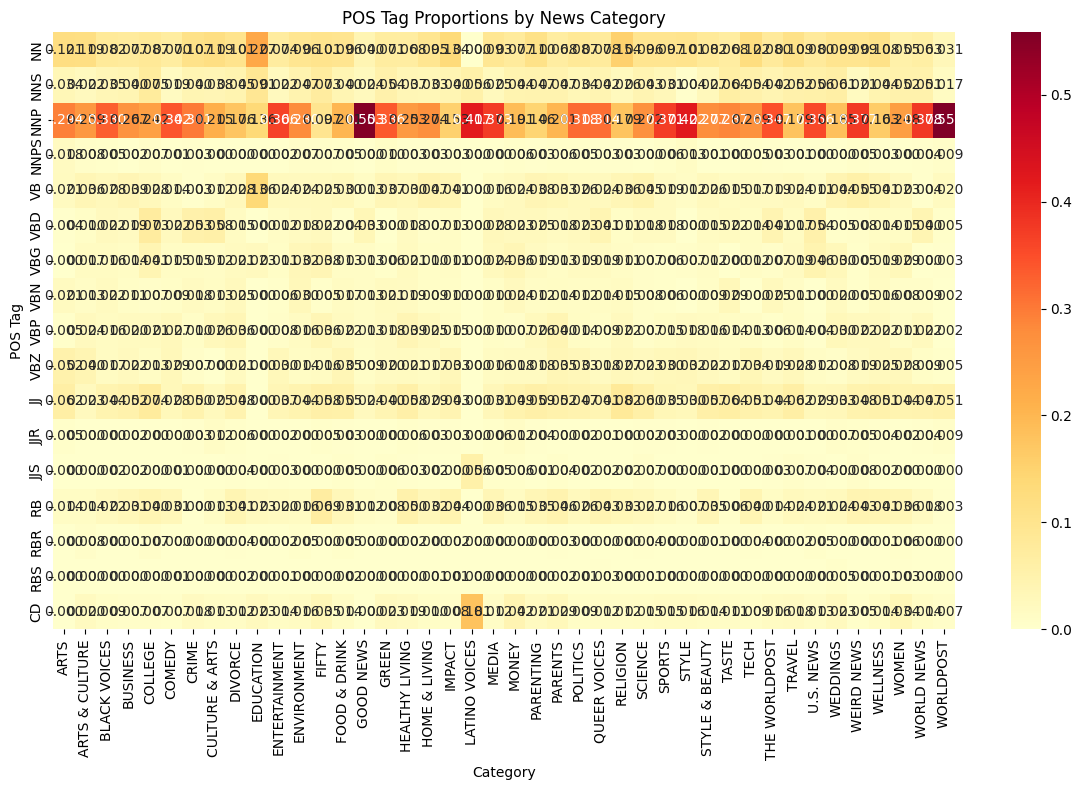


💡 ANALYSIS QUESTIONS:
1. Which category has the highest proportion of proper nouns (NNP/NNPS)?
2. Which category uses the most action verbs (VB, VBD, VBG)?
3. Are there interesting patterns in adjective (JJ) usage?
4. How does number (CD) usage vary across categories?


In [17]:
# Analyze POS patterns by category
print("📊 POS PATTERNS BY CATEGORY")
print("=" * 50)

# Group by category and calculate mean proportions
pos_by_category = pos_df.groupby('category').mean()

# Focus on major POS categories
major_pos = ['NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ',
             'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'CD']

# Filter to only include major POS tags that exist in our data
available_pos = [pos for pos in major_pos if pos in pos_by_category.columns]

if available_pos:
    pos_summary = pos_by_category[available_pos]

    print("\n🎯 Key POS patterns by category:")
    print(pos_summary.round(4))

    # Create visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(pos_summary.T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('POS Tag Proportions by News Category')
    plt.xlabel('Category')
    plt.ylabel('POS Tag')
    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Analyze the patterns
    # - Which categories use more nouns vs verbs?
    # - Do business articles have more numbers (CD)?
    # - Are there differences in adjective usage?

    print("\n💡 ANALYSIS QUESTIONS:")
    print("1. Which category has the highest proportion of proper nouns (NNP/NNPS)?")
    print("2. Which category uses the most action verbs (VB, VBD, VBG)?")
    print("3. Are there interesting patterns in adjective (JJ) usage?")
    print("4. How does number (CD) usage vary across categories?")
else:
    print("⚠️ No major POS tags found in the analysis. Check your POS tagging implementation.")

## 🌳 Syntax Parsing and Semantic Analysis

### 🎯 Module 5: Understanding Sentence Structure

Now we'll use spaCy to perform dependency parsing and extract semantic relationships from our news articles. This helps us understand not just what words are present, but how they relate to each other.

**Dependency Parsing Applications:**
- **Relationship Extraction:** Find connections between entities
- **Event Detection:** Identify who did what to whom
- **Information Extraction:** Extract structured facts from unstructured text

**💡 Business Value:** Understanding sentence structure helps extract more precise information about events, relationships, and actions mentioned in news articles.

In [19]:
def extract_syntactic_features(text):
    """
    Extract syntactic features using spaCy dependency parsing

    💡 TIP: This function should extract:
    - Dependency relations
    - Subject-verb-object patterns
    - Noun phrases
    - Verb phrases
    """
    if not text or pd.isna(text):
        return {}

    # Process text with spaCy
    doc = nlp(str(text))

    features = {
        'num_sentences': len(list(doc.sents)),
        'num_tokens': len(doc),
        'dependency_relations': [],
        'noun_phrases': [],
        'verb_phrases': [],
        'subjects': [],
        'objects': []
    }

    # 🚀 YOUR CODE HERE: Extract syntactic features

    # Extract dependency relations
    for token in doc:
        if not token.is_space and not token.is_punct:
            features['dependency_relations'].append(token.dep_)

    # Extract noun phrases
    for chunk in doc.noun_chunks:
        features['noun_phrases'].append(chunk.text.lower())

    # Extract subjects and objects
    for token in doc:
        if token.dep_ in ['nsubj', 'nsubjpass']:  # Subjects
            features['subjects'].append(token.text.lower())
        elif token.dep_ in ['dobj', 'iobj', 'pobj']:  # Objects
            features['objects'].append(token.text.lower())

    # Count dependency types
    dep_counts = Counter(features['dependency_relations'])
    features['dependency_counts'] = dict(dep_counts)

    return features

# Apply syntactic analysis to sample articles
print("🌳 Performing syntactic analysis...")

# Analyze first few articles (to save computation time)
syntactic_results = []
for idx, row in df_sample.head(5).iterrows():  # Limit to first 5 for demo
    features = extract_syntactic_features(row['full_text'])
    features['category'] = row['category']
    features['article_id'] = idx # Use the row index as article_id
    syntactic_results.append(features)

print("✅ Syntactic analysis complete!")

# Display results
for i, result in enumerate(syntactic_results):
    print(f"\n📰 Article {i+1} ({result['category']}):")
    print(f"  Sentences: {result['num_sentences']}")
    print(f"  Tokens: {result['num_tokens']}")
    print(f"  Noun phrases: {result['noun_phrases'][:3]}...")  # Show first 3
    print(f"  Subjects: {result['subjects'][:3]}...")  # Show first 3
    print(f"  Objects: {result['objects'][:3]}...")  # Show first 3

🌳 Performing syntactic analysis...
✅ Syntactic analysis complete!

📰 Article 1 (IMPACT):
  Sentences: 2
  Tokens: 45
  Noun phrases: ['we', 'all family generation changers', 'we']...
  Subjects: ['we', 'we', 'we']...
  Objects: ['opportunities', 'ourselves', 'ways']...

📰 Article 2 (BUSINESS):
  Sentences: 2
  Tokens: 29
  Noun phrases: ['aol', 'employee benefit cuts', 'it']...
  Subjects: ['it', 'earnings']...
  Objects: ['aol', 'cuts', 'armstrong']...

📰 Article 3 (POLITICS):
  Sentences: 2
  Tokens: 23
  Noun phrases: ['dakota access protesters', 'deadline passes', 'depart camp']...
  Subjects: ['protesters', 'protesters', 'who']...
  Objects: ['passes', 'camp', 'site']...

📰 Article 4 (GREEN):
  Sentences: 2
  Tokens: 12
  Noun phrases: ['one glimpse', 'these baby kit foxes', 'you']...
  Subjects: ['you']...
  Objects: ['foxes']...

📰 Article 5 (SCIENCE):
  Sentences: 2
  Tokens: 38
  Noun phrases: ["mens' sweat pheromone", 'androstadienone', 'influences cooperation']...
  Subjects

In [21]:
# Visualize dependency parsing for a sample sentence
from spacy import displacy

# Choose a sample sentence
sample_sentence = df_sample.iloc[0]['full_text']  # First article's content from the sampled data
print(f"📝 Sample sentence: {sample_sentence}")

# Process with spaCy
doc = nlp(sample_sentence)

# Display dependency tree (this works best in Jupyter)
print("\n🌳 Dependency Parse Visualization:")
try:
    # This will create an interactive visualization in Jupyter
    displacy.render(doc, style="dep", jupyter=True)
except:
    # Fallback: print dependency information
    print("\n🔗 Dependency Relations:")
    for token in doc:
        if not token.is_space and not token.is_punct:
            print(f"  {token.text} --> {token.dep_} --> {token.head.text}")

# 💡 STUDENT TASK: Extend syntactic analysis
# - Compare syntactic complexity across categories
# - Extract action patterns (who did what)
# - Identify most common dependency relations per category
# - Create features for classification based on syntax

📝 Sample sentence: What If We Were All Family Generation Changers? What if, in doing so, we won't just create new opportunities for ourselves, we'll also uncover ways to create new opportunities for our families that may not have otherwise existed?

🌳 Dependency Parse Visualization:


## 😊 Sentiment and Emotion Analysis

### 🎯 Module 6: Understanding Emotional Tone

Let's analyze the sentiment and emotional tone of our news articles. This can reveal interesting patterns about how different types of news are presented and perceived.

**Sentiment Analysis Applications:**
- **Media Bias Detection:** Identify emotional slant in news coverage
- **Public Opinion Tracking:** Monitor sentiment trends over time
- **Content Recommendation:** Suggest articles based on emotional tone

**💡 Hypothesis:** Different news categories might have different emotional profiles - sports might be more positive, politics more negative, etc.

In [22]:
# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """
    Analyze sentiment using VADER sentiment analyzer

    💡 TIP: VADER returns:
    - compound: overall sentiment (-1 to 1)
    - pos: positive score (0 to 1)
    - neu: neutral score (0 to 1)
    - neg: negative score (0 to 1)
    """
    if not text or pd.isna(text):
        # Ensure 'sentiment_label' is always present
        return {'compound': 0, 'pos': 0, 'neu': 1, 'neg': 0, 'sentiment_label': 'neutral'}

    # 🚀 YOUR CODE HERE: Implement sentiment analysis
    scores = sia.polarity_scores(str(text))

    # Add interpretation
    if scores['compound'] >= 0.05:
        scores['sentiment_label'] = 'positive'
    elif scores['compound'] <= -0.05:
        scores['sentiment_label'] = 'negative'
    else:
        scores['sentiment_label'] = 'neutral'

    return scores

# Apply sentiment analysis to all articles
print("😊 Analyzing sentiment...")

sentiment_results = []
for idx, row in df_sample.iterrows(): # Changed from df.iterrows() to df_sample.iterrows()
    # Analyze both title and content
    title_sentiment = analyze_sentiment(row['headline'])
    content_sentiment = analyze_sentiment(row['short_description'])
    full_sentiment = analyze_sentiment(row['full_text'])

    result = {
        'article_id': idx, # Use the row index as article_id
        'category': row['category'],
        'title_sentiment': title_sentiment['compound'],
        'title_label': title_sentiment['sentiment_label'],
        'content_sentiment': content_sentiment['compound'],
        'content_label': content_sentiment['sentiment_label'],
        'full_sentiment': full_sentiment['compound'],
        'full_label': full_sentiment['sentiment_label'],
        'pos_score': full_sentiment['pos'],
        'neu_score': full_sentiment['neu'],
        'neg_score': full_sentiment['neg']
    }
    sentiment_results.append(result)

# Convert to DataFrame
sentiment_df = pd.DataFrame(sentiment_results)

print("✅ Sentiment analysis complete!")
print(f"📊 Analyzed {len(sentiment_df)} articles")

# Display sample results
print("\n📝 Sample sentiment results:")
print(sentiment_df[['category', 'full_sentiment', 'full_label']].head())

😊 Analyzing sentiment...
✅ Sentiment analysis complete!
📊 Analyzed 700 articles

📝 Sample sentiment results:
   category  full_sentiment full_label
0    IMPACT          0.4464   positive
1  BUSINESS          0.7184   positive
2  POLITICS         -0.8074   negative
3     GREEN          0.0000    neutral
4   SCIENCE          0.3071   positive


📊 SENTIMENT ANALYSIS BY CATEGORY

📈 Sentiment statistics by category:
               full_sentiment                         pos_score neu_score  \
                         mean     std     min     max      mean      mean   
category                                                                    
ARTS                   0.7350  0.3097  0.2732  0.9267    0.2515    0.7485   
ARTS & CULTURE         0.0060  0.4340 -0.6486  0.5106    0.1027    0.8065   
BLACK VOICES          -0.1868  0.6009 -0.9468  0.9184    0.0582    0.8148   
BUSINESS               0.0770  0.5862 -0.9022  0.9668    0.1111    0.7594   
COLLEGE               -0.3688  0.1628 -0.6124 -0.2263    0.0576    0.7482   
COMEDY                 0.2649  0.3648 -0.2960  0.9601    0.1067    0.8581   
CRIME                 -0.5808  0.4439 -0.9371  0.2023    0.0193    0.7563   
CULTURE & ARTS        -0.0905  0.6389 -0.5423  0.3612    0.0315    0.9070   
DIVORCE               -0.1573  0.6515 -0.9162  0.8462    0.0817    0.8261   
EDUCAT

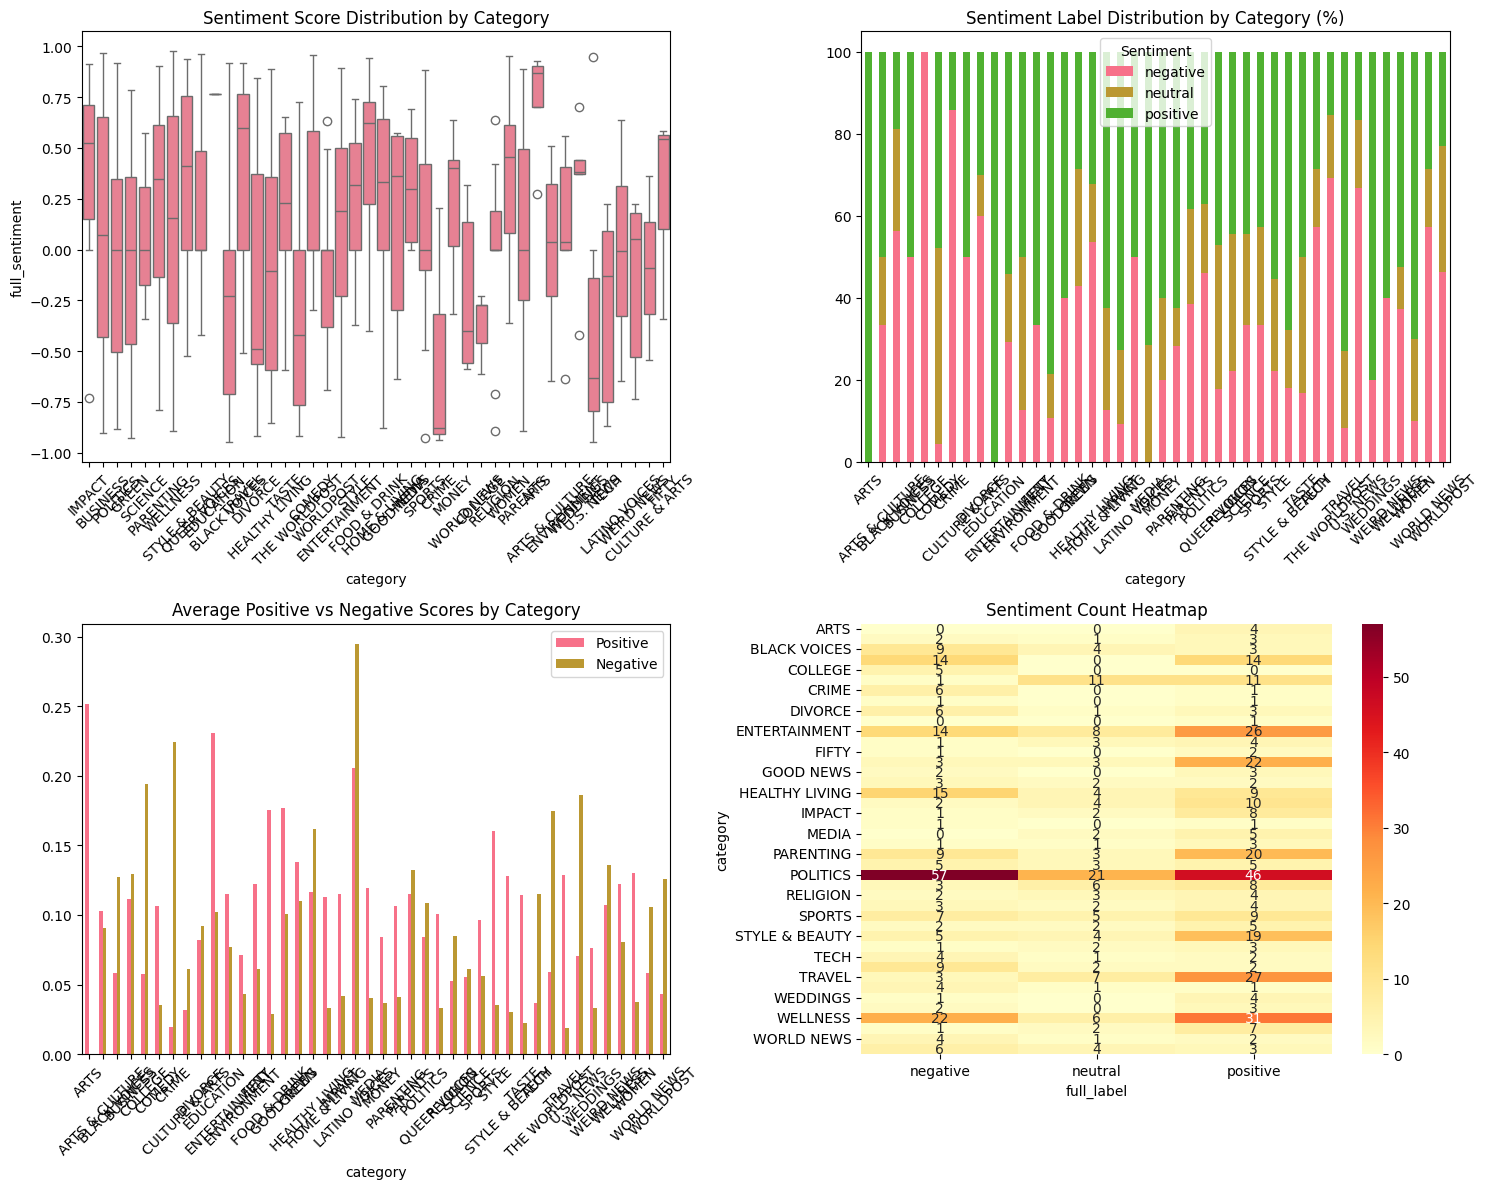

In [23]:
# Analyze sentiment patterns by category
print("📊 SENTIMENT ANALYSIS BY CATEGORY")
print("=" * 50)

# Calculate sentiment statistics by category
sentiment_by_category = sentiment_df.groupby('category').agg({
    'full_sentiment': ['mean', 'std', 'min', 'max'],
    'pos_score': 'mean',
    'neu_score': 'mean',
    'neg_score': 'mean'
}).round(4)

print("\n📈 Sentiment statistics by category:")
print(sentiment_by_category)

# Sentiment distribution by category
sentiment_dist = sentiment_df.groupby(['category', 'full_label']).size().unstack(fill_value=0)
sentiment_dist_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

print("\n📊 Sentiment distribution (%) by category:")
print(sentiment_dist_pct.round(2))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sentiment scores by category
sns.boxplot(data=sentiment_df, x='category', y='full_sentiment', ax=axes[0,0])
axes[0,0].set_title('Sentiment Score Distribution by Category')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Sentiment label distribution
sentiment_dist_pct.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Sentiment Label Distribution by Category (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Sentiment')

# 3. Positive vs Negative scores
category_means = sentiment_df.groupby('category')[['pos_score', 'neg_score']].mean()
category_means.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Positive vs Negative Scores by Category')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Positive', 'Negative'])

# 4. Sentiment vs Category heatmap
sentiment_pivot = sentiment_df.pivot_table(values='full_sentiment', index='category',
                                         columns='full_label', aggfunc='count', fill_value=0)
sns.heatmap(sentiment_pivot, annot=True, fmt='d', ax=axes[1,1], cmap='YlOrRd')
axes[1,1].set_title('Sentiment Count Heatmap')

plt.tight_layout()
plt.show()

# 💡 STUDENT TASK: Analyze sentiment patterns
# - Which categories are most positive/negative?
# - Are there differences between title and content sentiment?
# - How does sentiment vary within categories?
# - Can sentiment be used as a feature for classification?

## 🏷️ Text Classification System

### 🎯 Module 7: Building the News Classifier

Now we'll build the core of our NewsBot system - a multi-class text classifier that can automatically categorize news articles. We'll compare different algorithms and evaluate their performance.

**Classification Pipeline:**
1. **Feature Engineering:** Combine TF-IDF with other features
2. **Model Training:** Train multiple algorithms
3. **Model Evaluation:** Compare performance metrics
4. **Model Selection:** Choose the best performing model

**💡 Business Impact:** Accurate classification enables automatic content routing, personalized recommendations, and efficient content management.

In [25]:
# Prepare features for classification
print("🔧 Preparing features for classification...")

# 💡 TIP: Combine multiple feature types for better performance
# - TF-IDF features (most important)
# - Sentiment features
# - Text length features
# - POS features (if available)

# Recalculate TF-IDF on df_sample for consistency
tfidf_vectorizer_sample = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary for computational efficiency
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.8  # Ignore terms that appear in more than 80% of documents
)
tfidf_matrix_sample = tfidf_vectorizer_sample.fit_transform(df_sample['full_text_processed'])
X_tfidf = tfidf_matrix_sample.toarray()

# Add sentiment features
sentiment_features = sentiment_df[['full_sentiment', 'pos_score', 'neu_score', 'neg_score']].values

# Add text length features
length_features = np.array([
    df_sample['full_text'].str.len(),  # Character length
    df_sample['full_text'].str.split().str.len(),  # Word count
    df_sample['headline'].str.len(),  # Title length
]).T

# Combine all features
X_combined = np.hstack([
    X_tfidf,
    sentiment_features,
    length_features
])

# Target variable
y = df_sample['category'].values

print(f"✅ Feature matrix prepared!")
print(f"📊 Feature matrix shape: {X_combined.shape}")
print(f"🎯 Number of classes: {len(np.unique(y))}")
print(f"📋 Classes: {np.unique(y)}")

# Filter out categories with only one sample to avoid ValueError in stratified split
# First, combine features and target into a temporary DataFrame for easier filtering
temp_df = pd.DataFrame(X_combined)
temp_df['category'] = y

# Count occurrences of each category
category_counts = temp_df['category'].value_counts()

# Identify categories with only one sample
single_sample_categories = category_counts[category_counts == 1].index

# Filter out rows belonging to single-sample categories
temp_df_filtered = temp_df[~temp_df['category'].isin(single_sample_categories)]

# Separate features (X) and target (y) again from the filtered DataFrame
X_filtered = temp_df_filtered.drop('category', axis=1).values
y_filtered = temp_df_filtered['category'].values

print(f"\nFiltering complete. Original categories with single samples removed.")
print(f"New feature matrix shape: {X_filtered.shape}")
print(f"New number of classes: {len(np.unique(y_filtered))}")

# Split data into train and test sets using filtered data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"\n📈 Data split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

🔧 Preparing features for classification...
✅ Feature matrix prepared!
📊 Feature matrix shape: (700, 1987)
🎯 Number of classes: 42
📋 Classes: ['ARTS' 'ARTS & CULTURE' 'BLACK VOICES' 'BUSINESS' 'COLLEGE' 'COMEDY'
 'CRIME' 'CULTURE & ARTS' 'DIVORCE' 'EDUCATION' 'ENTERTAINMENT'
 'ENVIRONMENT' 'FIFTY' 'FOOD & DRINK' 'GOOD NEWS' 'GREEN' 'HEALTHY LIVING'
 'HOME & LIVING' 'IMPACT' 'LATINO VOICES' 'MEDIA' 'MONEY' 'PARENTING'
 'PARENTS' 'POLITICS' 'QUEER VOICES' 'RELIGION' 'SCIENCE' 'SPORTS' 'STYLE'
 'STYLE & BEAUTY' 'TASTE' 'TECH' 'THE WORLDPOST' 'TRAVEL' 'U.S. NEWS'
 'WEDDINGS' 'WEIRD NEWS' 'WELLNESS' 'WOMEN' 'WORLD NEWS' 'WORLDPOST']

Filtering complete. Original categories with single samples removed.
New feature matrix shape: (699, 1987)
New number of classes: 41

📈 Data split:
  Training set: 559 samples
  Test set: 140 samples


In [28]:
# Train and evaluate multiple classifiers
print("🤖 Training multiple classifiers...")

# Define classifiers to compare
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True)  # Enable probability for better analysis
}

# 💡 TIP: For larger datasets, you might want to use SGDClassifier for efficiency
# from sklearn.linear_model import SGDClassifier
# classifiers['SGD'] = SGDClassifier(random_state=42)

# Train and evaluate each classifier
results = {}
trained_models = {}

# The 'full_sentiment' column is the first of the sentiment_features,
# which are appended after the TF-IDF features. Its index is 1980.
# We need to make sure this index is accurate based on how X_combined was formed.
# X_combined = np.hstack([X_tfidf, sentiment_features, length_features])
# tfidf_matrix_sample.shape[1] gives the number of TF-IDF features.
# The 'full_sentiment' column starts right after these TF-IDF features.
full_sentiment_col_idx = tfidf_matrix_sample.shape[1] # Should be 1980

for name, classifier in classifiers.items():
    print(f"\n🔄 Training {name}...")

    # For MultinomialNB, shift negative sentiment values to be non-negative
    if name == 'Naive Bayes':
        X_train_nb = X_train.copy()
        X_test_nb = X_test.copy()
        # Shift the full_sentiment column (index `full_sentiment_col_idx`) by adding 1
        # This transforms the range from [-1, 1] to [0, 2]
        X_train_nb[:, full_sentiment_col_idx] = X_train_nb[:, full_sentiment_col_idx] + 1
        X_test_nb[:, full_sentiment_col_idx] = X_test_nb[:, full_sentiment_col_idx] + 1
        # Ensure no other unexpected negative values remain, though they shouldn't if sources are correct
        X_train_nb[X_train_nb < 0] = 0
        X_test_nb[X_test_nb < 0] = 0

        current_X_train = X_train_nb
        current_X_test = X_test_nb
    else:
        current_X_train = X_train
        current_X_test = X_test

    # 🚀 YOUR CODE HERE: Train and evaluate classifier
    # Train the model
    classifier.fit(current_X_train, y_train)

    # Make predictions
    y_pred = classifier.predict(current_X_test)
    y_pred_proba = classifier.predict_proba(current_X_test) if hasattr(classifier, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    # Cross-validation score
    cv_scores = cross_val_score(classifier, current_X_train, y_train, cv=3, scoring='accuracy')

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    trained_models[name] = classifier

    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  📊 CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n🏆 CLASSIFIER COMPARISON")
print("=" * 50)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
})

print(comparison_df.round(4))

# Find best model
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\n🥇 Best performing model: {best_model_name}")

🤖 Training multiple classifiers...

🔄 Training Naive Bayes...
  ✅ Accuracy: 0.2143
  📊 CV Score: 0.1878 (+/- 0.0088)

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.2357
  📊 CV Score: 0.2344 (+/- 0.0318)

🔄 Training SVM...
  ✅ Accuracy: 0.2143
  📊 CV Score: 0.2057 (+/- 0.0286)

🏆 CLASSIFIER COMPARISON
                 Model  Test Accuracy  CV Mean  CV Std
0          Naive Bayes         0.2143   0.1878  0.0044
1  Logistic Regression         0.2357   0.2344  0.0159
2                  SVM         0.2143   0.2057  0.0143

🥇 Best performing model: Logistic Regression


📊 DETAILED EVALUATION: Logistic Regression

📋 Classification Report:
                precision    recall  f1-score   support

          ARTS       0.00      0.00      0.00         1
ARTS & CULTURE       0.00      0.00      0.00         1
  BLACK VOICES       0.00      0.00      0.00         3
      BUSINESS       0.00      0.00      0.00         6
       COLLEGE       0.00      0.00      0.00         1
        COMEDY       0.00      0.00      0.00         5
         CRIME       0.00      0.00      0.00         1
       DIVORCE       0.00      0.00      0.00         2
 ENTERTAINMENT       0.20      0.20      0.20        10
   ENVIRONMENT       0.00      0.00      0.00         2
         FIFTY       0.00      0.00      0.00         1
  FOOD & DRINK       0.17      0.17      0.17         6
     GOOD NEWS       0.00      0.00      0.00         1
         GREEN       0.00      0.00      0.00         1
HEALTHY LIVING       0.00      0.00      0.00         6
 HOME & LIVING       0.00      0.0

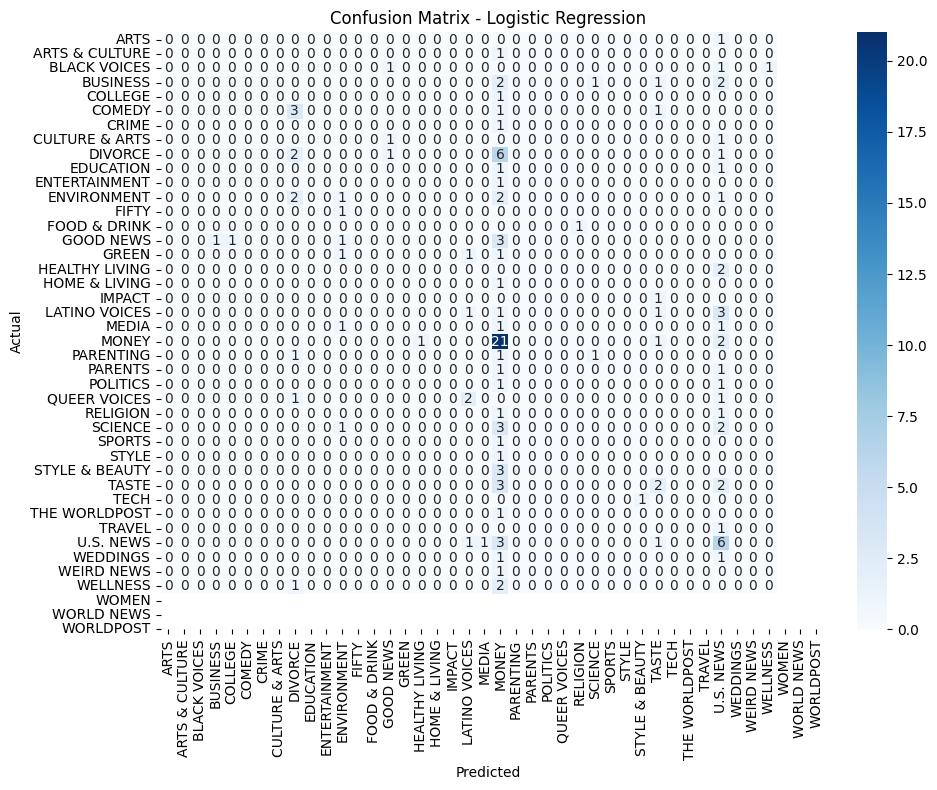


🔍 Top Features by Category:

📰 ARTS:
  sentiment: 1.2222
  map: 0.3936
  local: 0.3771
  pos_score: 0.3415
  control: 0.3385
  love: 0.3156
  great: 0.3150
  eye: 0.2972
  city: 0.2835
  show: 0.2696

📰 ARTS & CULTURE:
  book: 1.1389
  dream: 0.4880
  muslim: 0.3119
  islam: 0.3081
  hate: 0.2993
  fighting: 0.2913
  needed: 0.2866
  itd: 0.2814
  voting: 0.2797
  memoir: 0.2630

📰 BLACK VOICES:
  released: 0.5489
  dream: 0.5328
  mile: 0.5198
  birthday: 0.4853
  michael: 0.4809
  image: 0.4556
  love: 0.4408
  need: 0.4055
  recording: 0.3599
  central: 0.3583

📰 BUSINESS:
  neg_score: 1.1474
  problem: 0.8694
  womens: 0.6456
  business: 0.6228
  biggest: 0.5606
  pos_score: 0.5185
  executive: 0.5049
  employee: 0.5003
  version: 0.4833
  world: 0.4669

📰 COLLEGE:
  student: 0.4262
  combat: 0.4139
  char_length: 0.3768
  plan: 0.3339
  harvard: 0.3167
  neg_score: 0.3153
  officially: 0.3143
  improve: 0.2619
  relationship: 0.2589
  broke: 0.2537

📰 COMEDY:
  sentiment: 0.9706


In [31]:
# Detailed evaluation of the best model
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

print(f"📊 DETAILED EVALUATION: {best_model_name}")
print("=" * 60)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, best_predictions))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (for Logistic Regression)
if best_model_name == 'Logistic Regression':
    print("\n🔍 Top Features by Category:")
    feature_names_extended = list(feature_names) + ['sentiment', 'pos_score', 'neu_score', 'neg_score',
                                                   'char_length', 'word_count', 'title_length']

    classes = best_model.classes_
    coefficients = best_model.coef_

    for i, class_name in enumerate(classes):
        top_indices = np.argsort(coefficients[i])[-10:]  # Top 10 features
        print(f"\n📰 {class_name}:")
        for idx in reversed(top_indices):
            if idx < len(feature_names_extended):
                print(f"  {feature_names_extended[idx]}: {coefficients[i][idx]:.4f}")

# 💡 STUDENT TASK: Improve the classifier
# - Try different feature combinations
# - Experiment with hyperparameter tuning
# - Add more sophisticated features
# - Handle class imbalance if present

## 🔍 Named Entity Recognition

### 🎯 Module 8: Extracting Facts from News

Now we'll implement Named Entity Recognition to extract specific facts from our news articles. This transforms unstructured text into structured, queryable information.

**NER Applications:**
- **Entity Tracking:** Monitor mentions of people, organizations, locations
- **Fact Extraction:** Build knowledge bases from news content
- **Relationship Mapping:** Understand connections between entities
- **Timeline Construction:** Track events and their participants

**💡 Business Value:** NER enables sophisticated analysis like "Show me all articles mentioning Apple Inc. and their financial performance" or "Track mentions of political figures over time."

In [32]:
def extract_entities(text):
    """
    Extract named entities using spaCy

    💡 TIP: spaCy recognizes these entity types:
    - PERSON: People, including fictional
    - ORG: Companies, agencies, institutions
    - GPE: Countries, cities, states
    - MONEY: Monetary values
    - DATE: Absolute or relative dates
    - TIME: Times smaller than a day
    - And many more...
    """
    if not text or pd.isna(text):
        return []

    # 🚀 YOUR CODE HERE: Implement entity extraction
    doc = nlp(str(text))

    entities = []
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
            'description': spacy.explain(ent.label_)
        })

    return entities

# Apply NER to all articles
print("🔍 Extracting named entities...")

all_entities = []
article_entities = []

for idx, row in df_sample.iterrows(): # Changed from df.iterrows() to df_sample.iterrows()
    entities = extract_entities(row['full_text'])

    # Store entities for this article
    article_entities.append({
        'article_id': idx,
        'category': row['category'],
        'entities': entities,
        'entity_count': len(entities)
    })

    # Add to global entity list
    for entity in entities:
        entity['article_id'] = idx # Use the row index as article_id
        entity['category'] = row['category']
        all_entities.append(entity)

print(f"✅ Entity extraction complete!")
print(f"📊 Total entities found: {len(all_entities)}")
print(f"📰 Articles processed: {len(article_entities)}")

# Convert to DataFrame for analysis
entities_df = pd.DataFrame(all_entities)

if not entities_df.empty:
    print(f"\n🏷️ Entity types found: {entities_df['label'].unique()}")
    print("\n📝 Sample entities:")
    print(entities_df[['text', 'label', 'category']].head(10))
else:
    print("⚠️ No entities found. This might happen with very short sample texts.")

🔍 Extracting named entities...
✅ Entity extraction complete!
📊 Total entities found: 1759
📰 Articles processed: 700

🏷️ Entity types found: ['ORG' 'PERSON' 'DATE' 'CARDINAL' 'EVENT' 'GPE' 'ORDINAL' 'WORK_OF_ART'
 'NORP' 'PERCENT' 'LOC' 'FAC' 'PRODUCT' 'MONEY' 'TIME' 'LAW' 'QUANTITY'
 'LANGUAGE']

📝 Sample entities:
                                                text     label  category
0                                                AOL       ORG  BUSINESS
1                                                AOL       ORG  BUSINESS
2                                      Tim Armstrong    PERSON  BUSINESS
3                                          quarterly      DATE  BUSINESS
4                                           Thursday      DATE  BUSINESS
5  Dakota Access Protesters Arrested As Deadline ...       ORG  POLITICS
6                                           Thursday      DATE  POLITICS
7                                                One  CARDINAL     GREEN
8                         

📊 NAMED ENTITY ANALYSIS

🏷️ Entity type distribution:
label
PERSON         527
ORG            392
DATE           207
GPE            189
CARDINAL       164
WORK_OF_ART     74
NORP            71
ORDINAL         29
LOC             19
TIME            17
MONEY           13
FAC             13
PRODUCT         13
EVENT           12
PERCENT          7
QUANTITY         6
LAW              4
LANGUAGE         2
Name: count, dtype: int64

📰 Entity types by news category:
label           CARDINAL  DATE  EVENT  FAC  GPE  LANGUAGE  LAW  LOC  MONEY  \
category                                                                     
ARTS                   0     0      0    0    1         2    0    0      0   
ARTS & CULTURE         0     3      0    0    3         0    0    0      0   
BLACK VOICES           0     7      0    2    6         0    0    0      0   
BUSINESS               3    10      1    0    4         0    1    2      1   
COLLEGE                1     3      0    0    0         0    0    0   

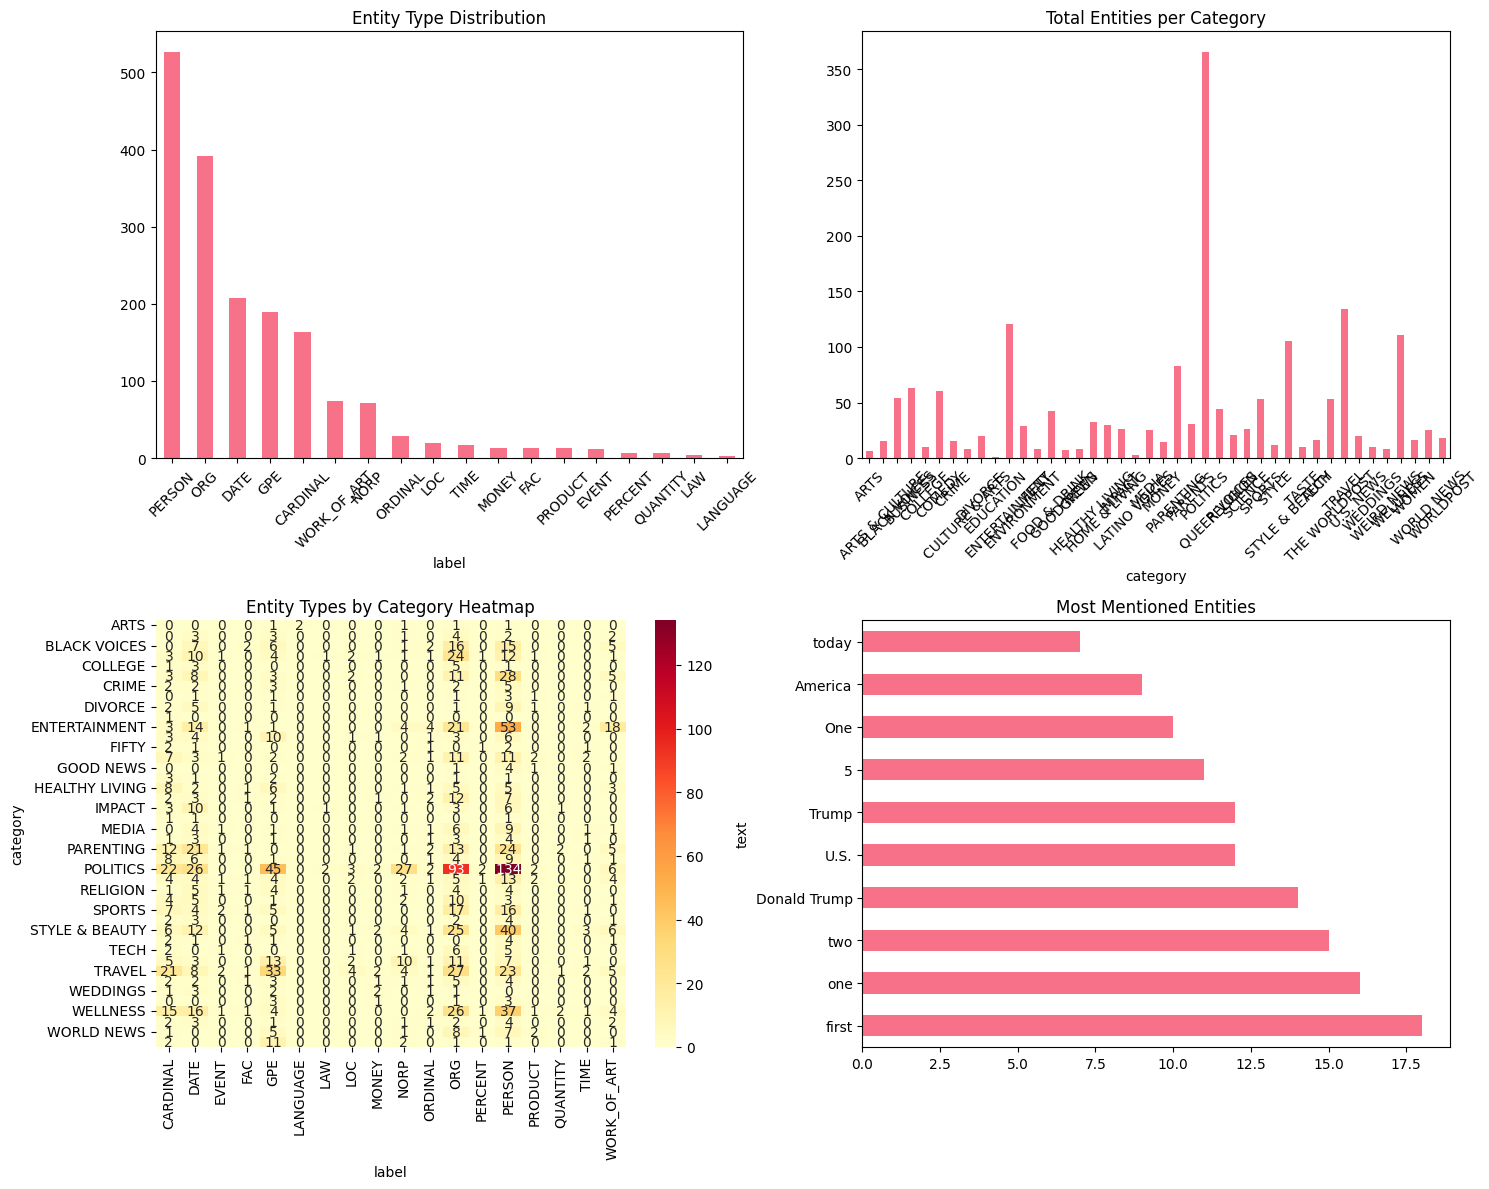

In [33]:
# Analyze entity patterns
if not entities_df.empty:
    print("📊 NAMED ENTITY ANALYSIS")
    print("=" * 50)

    # Entity type distribution
    entity_counts = entities_df['label'].value_counts()
    print("\n🏷️ Entity type distribution:")
    print(entity_counts)

    # Entity types by category
    entity_by_category = entities_df.groupby(['category', 'label']).size().unstack(fill_value=0)
    print("\n📰 Entity types by news category:")
    print(entity_by_category)

    # Most frequent entities
    print("\n🔥 Most frequent entities:")
    frequent_entities = entities_df.groupby(['text', 'label']).size().sort_values(ascending=False).head(15)
    for (entity, label), count in frequent_entities.items():
        print(f"  {entity} ({label}): {count} mentions")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Entity type distribution
    entity_counts.plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Entity Type Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. Entities per category
    entities_per_category = entities_df.groupby('category').size()
    entities_per_category.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Total Entities per Category')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Entity type heatmap by category
    if entity_by_category.shape[0] > 1 and entity_by_category.shape[1] > 1:
        sns.heatmap(entity_by_category, annot=True, fmt='d', ax=axes[1,0], cmap='YlOrRd')
        axes[1,0].set_title('Entity Types by Category Heatmap')
    else:
        axes[1,0].text(0.5, 0.5, 'Insufficient data\nfor heatmap',
                      ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Entity Types by Category')

    # 4. Top entities
    top_entities = entities_df['text'].value_counts().head(10)
    top_entities.plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Most Mentioned Entities')

    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Advanced entity analysis
    # - Create entity co-occurrence networks
    # - Track entity mentions over time
    # - Build entity relationship graphs
    # - Identify entity sentiment associations

else:
    print("⚠️ Skipping entity analysis due to insufficient data.")
    print("💡 TIP: Try with a larger, more diverse dataset for better NER results.")

## 📈 Comprehensive Analysis and Insights

### 🎯 Bringing It All Together

Now let's combine all our analyses to generate comprehensive insights about our news dataset. This is where the real business value emerges from our NLP pipeline.

**Key Analysis Areas:**
1. **Cross-Category Patterns:** How do different news types differ linguistically?
2. **Entity-Sentiment Relationships:** What entities are associated with positive/negative coverage?
3. **Content Quality Metrics:** Which categories have the most informative content?
4. **Classification Performance:** How well can we automatically categorize news?

**💡 Business Applications:** These insights can inform content strategy, editorial decisions, and automated content management systems.

In [34]:
# Create comprehensive analysis dashboard
def create_comprehensive_analysis():
    """
    Generate comprehensive insights combining all analyses

    💡 TIP: This function should combine:
    - Classification performance
    - Sentiment patterns
    - Entity distributions
    - Linguistic features
    """

    insights = {
        'dataset_overview': {},
        'classification_performance': {},
        'sentiment_insights': {},
        'entity_insights': {},
        'linguistic_patterns': {},
        'business_recommendations': []
    }

    # 🚀 YOUR CODE HERE: Generate comprehensive insights

    # Dataset overview
    insights['dataset_overview'] = {
        'total_articles': len(df_sample), # Changed from len(df) to len(df_sample)
        'categories': df_sample['category'].unique().tolist(), # Changed from df['category'].unique() to df_sample['category'].unique()
        'category_distribution': df_sample['category'].value_counts().to_dict(), # Changed from df['category'].value_counts() to df_sample['category'].value_counts()
        'avg_article_length': df_sample['full_text'].str.len().mean(), # Changed from df['full_text'].str.len() to df_sample['full_text'].str.len()
        'avg_words_per_article': df_sample['full_text'].str.split().str.len().mean() # Changed from df['full_text'].str.split() to df_sample['full_text'].str.split()
    }

    # Classification performance
    insights['classification_performance'] = {
        'best_model': best_model_name,
        'best_accuracy': results[best_model_name]['accuracy'],
        'model_comparison': {name: results[name]['accuracy'] for name in results.keys()}
    }

    # Sentiment insights
    sentiment_by_cat = sentiment_df.groupby('category')['full_sentiment'].mean().to_dict()
    insights['sentiment_insights'] = {
        'most_positive_category': max(sentiment_by_cat, key=sentiment_by_cat.get),
        'most_negative_category': min(sentiment_by_cat, key=sentiment_by_cat.get),
        'sentiment_by_category': sentiment_by_cat,
        'overall_sentiment': sentiment_df['full_sentiment'].mean()
    }

    # Entity insights
    if not entities_df.empty:
        entity_by_cat = entities_df.groupby('category').size().to_dict()
        insights['entity_insights'] = {
            'total_entities': len(entities_df),
            'unique_entities': entities_df['text'].nunique(),
            'entity_types': entities_df['label'].unique().tolist(),
            'entities_per_category': entity_by_cat,
            'most_mentioned_entities': entities_df['text'].value_counts().head(5).to_dict()
        }

    # Generate business recommendations
    recommendations = []

    # Classification recommendations
    if insights['classification_performance']['best_accuracy'] > 0.8:
        recommendations.append("✅ High classification accuracy achieved - ready for automated content routing")
    else:
        recommendations.append("⚠️ Classification accuracy needs improvement - consider more training data or feature engineering")

    # Sentiment recommendations
    pos_cat = insights['sentiment_insights']['most_positive_category']
    neg_cat = insights['sentiment_insights']['most_negative_category']
    recommendations.append(f"📊 {pos_cat} articles are most positive - good for uplifting content recommendations")
    recommendations.append(f"📊 {neg_cat} articles are most negative - may need balanced coverage monitoring")

    # Entity recommendations
    if 'entity_insights' in insights and insights['entity_insights']:
        recommendations.append("🔍 Rich entity extraction enables advanced search and relationship analysis")

    insights['business_recommendations'] = recommendations

    return insights

# Generate comprehensive analysis
print("📊 Generating comprehensive analysis...")
analysis_results = create_comprehensive_analysis()

print("✅ Analysis complete!")
print("\n" + "=" * 60)
print("📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT")
print("=" * 60)

# Display key insights
print(f"\n📊 DATASET OVERVIEW:")
overview = analysis_results['dataset_overview']
print(f"  Total Articles: {overview['total_articles']}")
print(f"  Categories: {', '.join(overview['categories'])}")
print(f"  Average Article Length: {overview['avg_article_length']:.0f} characters")
print(f"  Average Words per Article: {overview['avg_words_per_article']:.0f} words")

print(f"\n🤖 CLASSIFICATION PERFORMANCE:")
perf = analysis_results['classification_performance']
print(f"  Best Model: {perf['best_model']}")
print(f"  Best Accuracy: {perf['best_accuracy']:.4f}")

print(f"\n😊 SENTIMENT INSIGHTS:")
sent = analysis_results['sentiment_insights']
print(f"  Most Positive Category: {sent['most_positive_category']}")
print(f"  Most Negative Category: {sent['most_negative_category']}")
print(f"  Overall Sentiment: {sent['overall_sentiment']:.4f}")

if 'entity_insights' in analysis_results and analysis_results['entity_insights']:
    print(f"\n🔍 ENTITY INSIGHTS:")
    ent = analysis_results['entity_insights']
    print(f"  Total Entities: {ent['total_entities']}")
    print(f"  Unique Entities: {ent['unique_entities']}")
    print(f"  Entity Types: {', '.join(ent['entity_types'])}")

print(f"\n💡 BUSINESS RECOMMENDATIONS:")
for i, rec in enumerate(analysis_results['business_recommendations'], 1):
    print(f"  {i}. {rec}")

📊 Generating comprehensive analysis...
✅ Analysis complete!

📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT

📊 DATASET OVERVIEW:
  Total Articles: 700
  Categories: IMPACT, BUSINESS, POLITICS, GREEN, SCIENCE, PARENTING, WELLNESS, STYLE & BEAUTY, QUEER VOICES, EDUCATION, BLACK VOICES, TRAVEL, DIVORCE, HEALTHY LIVING, TASTE, THE WORLDPOST, COMEDY, WORLDPOST, ENTERTAINMENT, STYLE, FOOD & DRINK, HOME & LIVING, GOOD NEWS, MEDIA, SPORTS, CRIME, MONEY, WORLD NEWS, COLLEGE, RELIGION, WOMEN, PARENTS, ARTS, ARTS & CULTURE, ENVIRONMENT, WEDDINGS, U.S. NEWS, TECH, LATINO VOICES, WEIRD NEWS, CULTURE & ARTS, FIFTY
  Average Article Length: 169 characters
  Average Words per Article: 29 words

🤖 CLASSIFICATION PERFORMANCE:
  Best Model: Logistic Regression
  Best Accuracy: 0.2357

😊 SENTIMENT INSIGHTS:
  Most Positive Category: EDUCATION
  Most Negative Category: CRIME
  Overall Sentiment: 0.1017

🔍 ENTITY INSIGHTS:
  Total Entities: 1759
  Unique Entities: 1377
  Entity Types: ORG, PERSON, DAT

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [ ] Complete Jupyter notebook with all analyses
- [ ] Well-documented functions with docstrings
- [ ] Clear markdown explanations for each section
- [ ] Organized GitHub repository structure
- [ ] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [ ] Comprehensive dataset exploration
- [ ] TF-IDF analysis with category-specific insights
- [ ] POS tagging patterns across categories
- [ ] Syntactic analysis with dependency parsing
- [ ] Sentiment analysis with category comparisons
- [ ] Classification model comparison and evaluation
- [ ] Named Entity Recognition with relationship mapping
- [ ] Integrated system demonstration

### 📈 Visualizations
- [ ] Category distribution plots
- [ ] TF-IDF word clouds or bar charts
- [ ] POS pattern heatmaps
- [ ] Sentiment distribution by category
- [ ] Confusion matrix for classification
- [ ] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [ ] Written report (3-4 pages)
- [ ] Individual reflection papers
- [ ] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*